# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для оценки рыночной стоимости автомобилей. Задача — построить модель, которая по техническим характеристикам и комплектации определяет цену.

**Критерии заказчика:**
- Качество предсказания (RMSE < 2500 евро)
- Скорость обучения — модель должна переобучаться на свежих данных без долгих простоев
- Скорость предсказания — ответ пользователю приложения должен быть мгновенным

**План исследования:**
1. Загрузка и первичный осмотр данных
2. Разведочный анализ (EDA)
3. Подготовка данных
4. Обучение и сравнение моделей
5. Тонкая настройка лучшей модели
6. Тестирование финальной модели
7. Выводы

## 1. Загрузка данных

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb

pd.set_option('display.max_columns', 20)

In [42]:
df = pd.read_csv('./datasets/autos.csv')
display(df.info())
display(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

None

(354369, 16)

In [43]:
display(df.head(10))

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,2016-04-04 17:36:23,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,2016-04-01 20:48:51,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,2016-03-21 18:54:38,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
8,2016-04-04 23:42:13,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,2016-04-04 00:00:00,0,94505,2016-04-04 23:42:13
9,2016-03-17 10:53:50,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,2016-03-17 00:00:00,0,27472,2016-03-31 17:17:06


In [44]:
display(df.describe())

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [45]:
display(df.isnull().sum())

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

Пропуски в `VehicleType`, `Gearbox`, `Model`, `FuelType`, `Repaired`. Числовые признаки `Power` и `RegistrationYear` требуют проверки на аномалии. Столбец `NumberOfPictures` подозрительно однороден.

## 2. Разведочный анализ (EDA)

Посмотрим на распределения признаков, чтобы принять обоснованные решения по очистке данных.

### Целевая переменная — Price

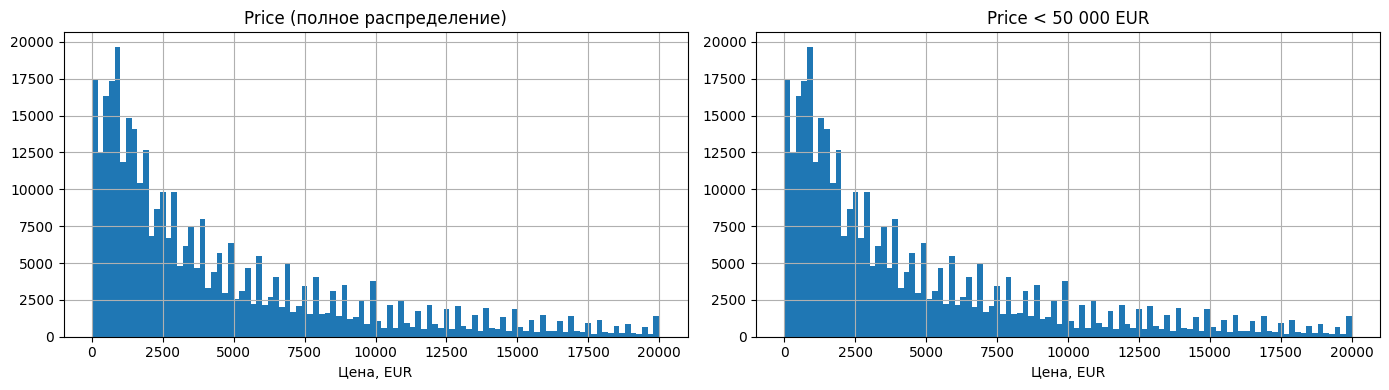

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Price'].hist(bins=100, ax=axes[0])
axes[0].set_title('Price (полное распределение)')
axes[0].set_xlabel('Цена, EUR')
df[df['Price'] < 50000]['Price'].hist(bins=100, ax=axes[1])
axes[1].set_title('Price < 50 000 EUR')
axes[1].set_xlabel('Цена, EUR')
plt.tight_layout()
plt.show()

Большинство автомобилей стоит до 20 000 EUR. Есть выбросы с ценой 0 и экстремально высокими значениями — бесплатные и коллекционные автомобили не представляют целевую аудиторию сервиса.

### Числовые признаки

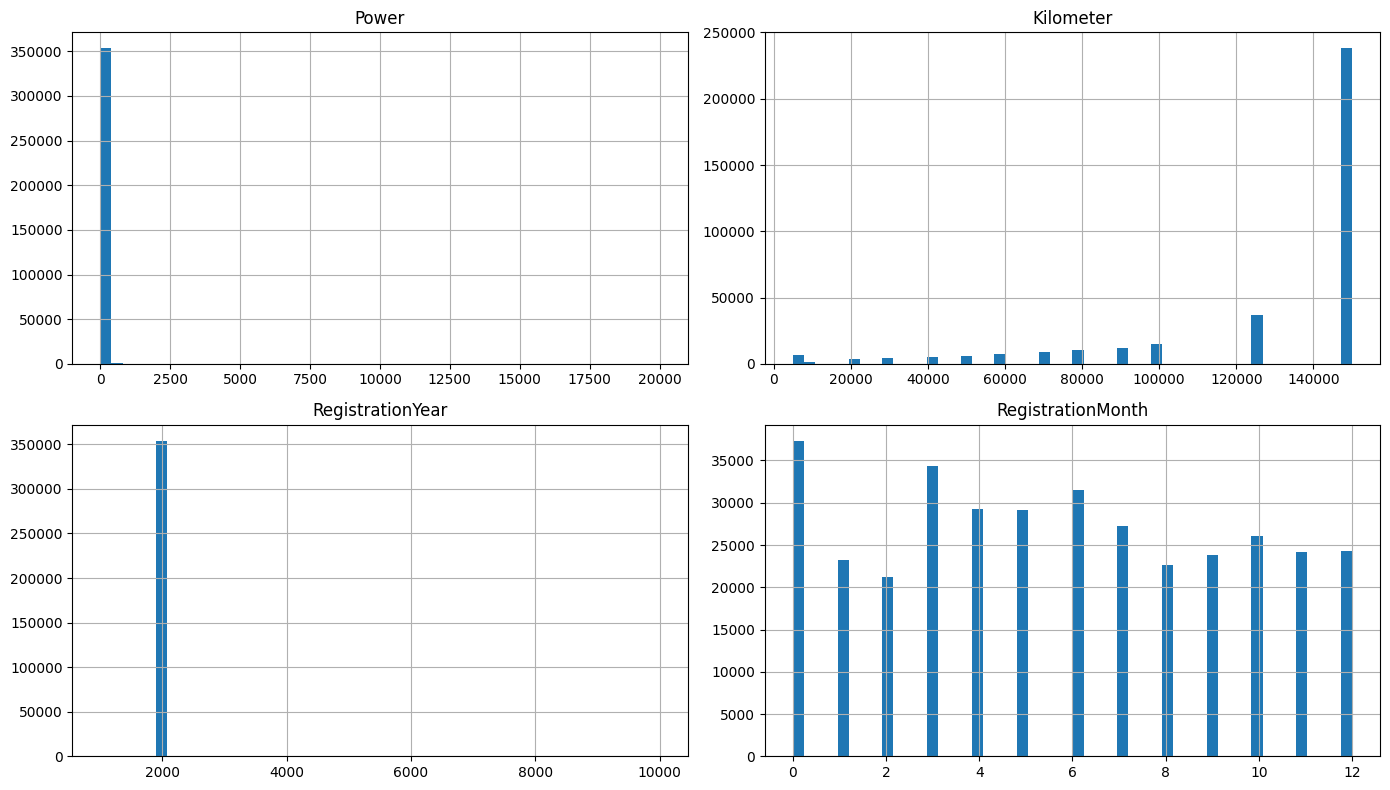

In [47]:
num_cols = ['Power', 'Kilometer', 'RegistrationYear', 'RegistrationMonth']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

- **Power**: пик на 0 — это пропуски, замаскированные нулями. Есть выбросы свыше 1000 л.с.
- **Kilometer**: дискретные значения (шаг 5000 км) — данные округлены продавцами.
- **RegistrationYear**: основная масса 1995–2016. Значения до 1900 и после 2016 — аномалии (данные собраны в 2016).
- **RegistrationMonth**: 0 означает отсутствие данных.

### Категориальные признаки

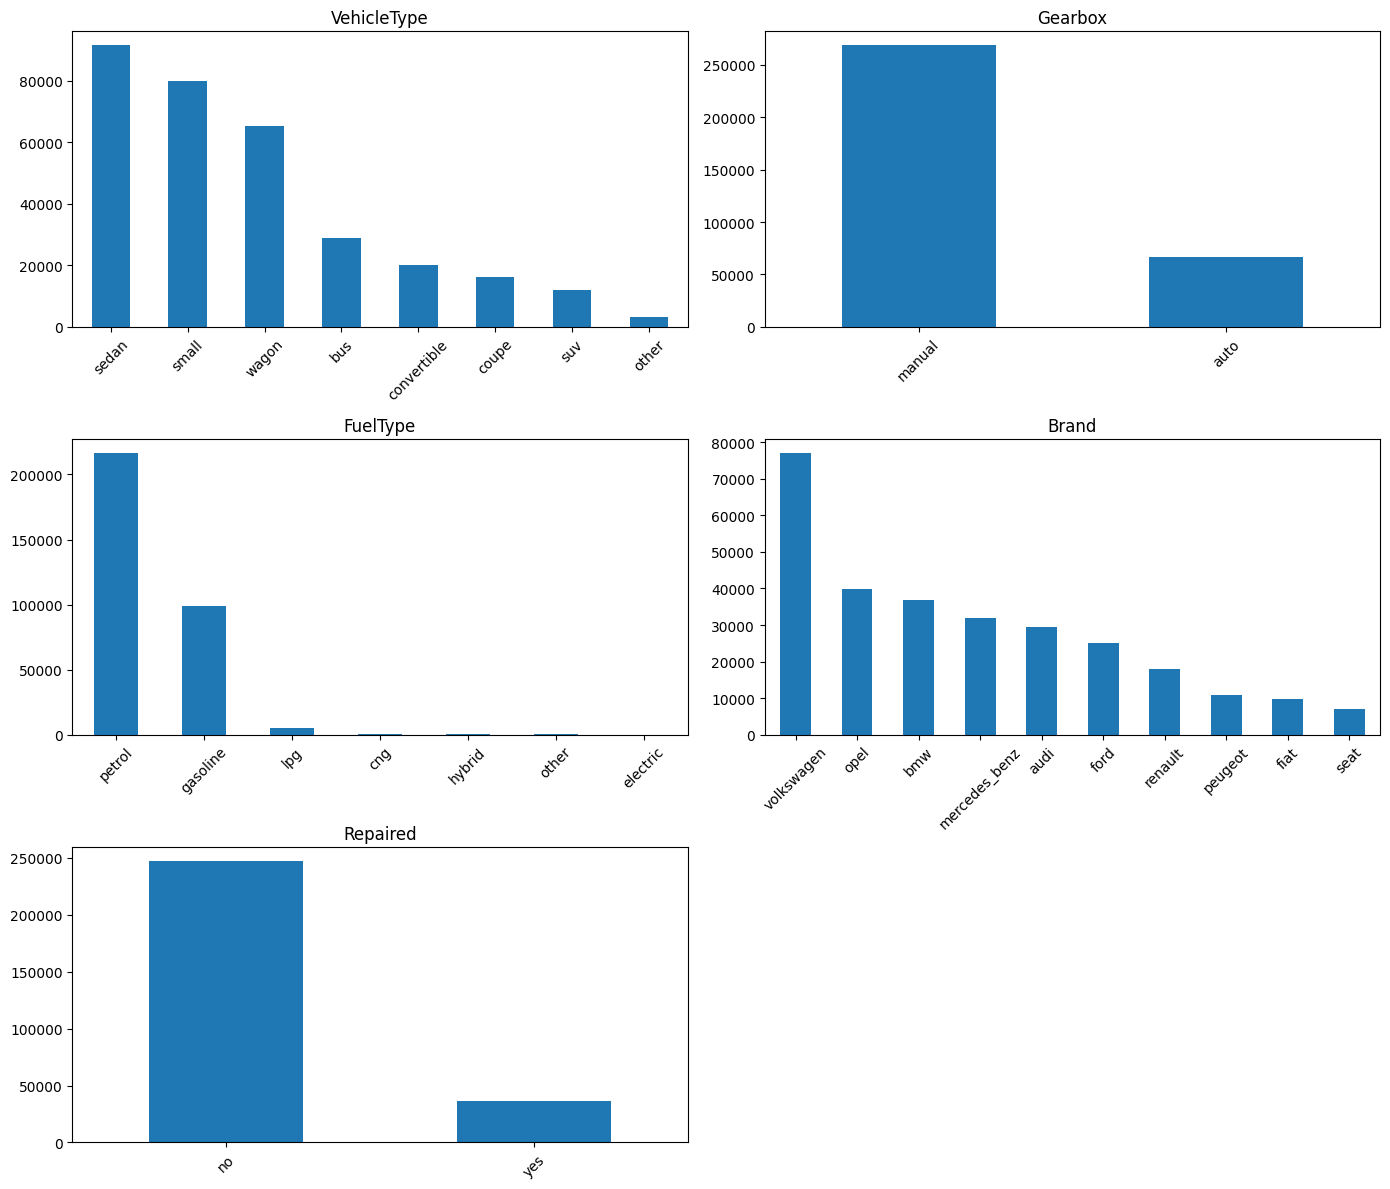

In [48]:
cat_features = ['VehicleType', 'Gearbox', 'FuelType', 'Brand', 'Repaired']
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, col in zip(axes.flatten(), cat_features):
    df[col].value_counts().head(10).plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
axes[-1, -1].axis('off')
plt.tight_layout()
plt.show()

- **VehicleType**: лидируют sedan и small — типичный европейский рынок.
- **Gearbox**: механика преобладает (Германия), автомат — около трети.
- **FuelType**: бензин и дизель покрывают >90% рынка.
- **Brand**: Volkswagen, BMW, Opel, Mercedes — топ-4 по объявлениям.
- **Repaired**: большинство не ремонтировались; для покупателя это ключевой фактор доверия.

In [49]:
display(df['NumberOfPictures'].value_counts())

0    354369
Name: NumberOfPictures, dtype: int64

### Корреляция числовых признаков с ценой

In [50]:
display(df.select_dtypes(include=[np.number]).corr()['Price'].sort_values(ascending=False))

Price                1.000000
Power                0.158872
RegistrationMonth    0.110581
PostalCode           0.076055
RegistrationYear     0.026916
Kilometer           -0.333199
NumberOfPictures          NaN
Name: Price, dtype: float64

`NumberOfPictures` содержит только нули — признак неинформативен.

### Промежуточные выводы EDA

Основные закономерности: цена сильнее всего коррелирует с мощностью и годом регистрации, отрицательно — с пробегом. Категориальные признаки (марка, тип кузова, КПП) также значимы для ценообразования. Выявлены аномалии в Price, Power и RegistrationYear — будут очищены на следующем этапе.

Удалим признаки, не влияющие на рыночную стоимость: даты скачивания/создания/активности (технические метаданные площадки), `NumberOfPictures` (нули), `PostalCode` (слишком гранулярный — почтовый индекс не определяет цену на уровне модели).

In [51]:
df = df.drop(['DateCrawled', 'DateCreated', 'LastSeen', 'NumberOfPictures', 'PostalCode'], axis=1)
display(df.columns.tolist())

['Price',
 'VehicleType',
 'RegistrationYear',
 'Gearbox',
 'Power',
 'Model',
 'Kilometer',
 'RegistrationMonth',
 'FuelType',
 'Brand',
 'Repaired']

Очистим аномалии. Пороги выбраны исходя из реалий рынка подержанных автомобилей:
- **Price**: объявления дешевле 100 EUR — подарки, обмены, ошибки ввода. Дороже 200 000 EUR — коллекционные авто, не целевой сегмент сервиса.
- **RegistrationYear**: до 1950 — антиквариат, после 2016 — ошибки (данные собраны в 2016).
- **Power**: 0 л.с. — пропуск, более 1000 л.с. — суперкары или ошибки.

In [52]:
display(f'До очистки: {df.shape[0]} строк')

df = df[(df['Price'] > 100) & (df['Price'] < 200000)]
df = df[(df['RegistrationYear'] >= 1950) & (df['RegistrationYear'] <= 2016)]
df = df[(df['Power'] > 0) & (df['Power'] < 1000)]

display(f'После очистки: {df.shape[0]} строк')

'До очистки: 354369 строк'

'После очистки: 294796 строк'

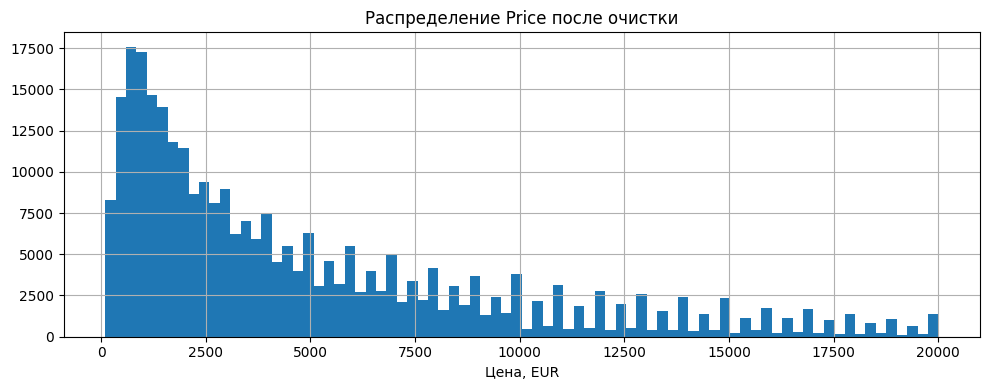

In [53]:
fig, ax = plt.subplots(figsize=(10, 4))
df['Price'].hist(bins=80, ax=ax)
ax.set_title('Распределение Price после очистки')
ax.set_xlabel('Цена, EUR')
plt.tight_layout()
plt.show()

После очистки распределение стало более однородным — основная масса объявлений в диапазоне 500–15 000 EUR.

`RegistrationMonth=0` означает отсутствие данных о месяце регистрации. Оставляем как есть — месяц регистрации слабо влияет на цену подержанного авто.

Заполним пропуски в категориальных признаках модой — для порядкового кодирования это безопаснее, чем оставлять NaN.

In [54]:
cat_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

display(df.isnull().sum())

Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Kilometer            0
RegistrationMonth    0
FuelType             0
Brand                0
Repaired             0
dtype: int64

Закодируем категории порядковыми числами и добавим возраст автомобиля — более интерпретируемый признак, чем год регистрации.

In [55]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[cat_cols] = encoder.fit_transform(df[cat_cols])

df['VehicleAge'] = 2016 - df['RegistrationYear']

display(df.head())

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,VehicleAge
1,18300,2.0,2011,1.0,190,116.0,125000,5,2.0,1.0,1.0,5
2,9800,6.0,2004,0.0,163,117.0,125000,8,2.0,14.0,0.0,12
3,1500,5.0,2001,1.0,75,116.0,150000,6,6.0,38.0,0.0,15
4,3600,5.0,2008,1.0,69,101.0,90000,7,2.0,31.0,0.0,8
5,650,4.0,1995,1.0,102,11.0,150000,10,6.0,2.0,1.0,21


Разделим данные на три выборки: обучающую (60%), валидационную (20%) и тестовую (20%). Тестовая будет использована только один раз — для финальной оценки.

In [56]:
target = df['Price']
features = df.drop('Price', axis=1)

features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=12345
)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=12345
)

display(f'Обучающая: {features_train.shape}')
display(f'Валидационная: {features_valid.shape}')
display(f'Тестовая: {features_test.shape}')

'Обучающая: (176877, 11)'

'Валидационная: (58959, 11)'

'Тестовая: (58960, 11)'

## 4. Обучение и сравнение моделей

Сравним пять типов моделей — от линейных до градиентного бустинга. Для каждой замерим RMSE, время обучения и время предсказания.

In [57]:
results = []

def evaluate_model(name, model, X_train, y_train, X_valid, y_valid):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    start = time.time()
    predictions = model.predict(X_valid)
    predict_time = time.time() - start
    
    rmse = mean_squared_error(y_valid, predictions) ** 0.5
    
    results.append({
        'Модель': name,
        'RMSE': round(rmse, 2),
        'Время обучения (с)': round(train_time, 2),
        'Время предсказания (с)': round(predict_time, 4)
    })
    
    display(f'{name}: RMSE={rmse:.2f}, обучение={train_time:.2f}с, предсказание={predict_time:.4f}с')
    return model

### 4.1 Линейная регрессия

Начнём с простейшей модели — она покажет нижнюю границу качества и поможет понять, нужны ли более сложные подходы.

In [58]:
%%time
evaluate_model('LinearRegression', LinearRegression(),
               features_train, target_train, features_valid, target_valid)

'LinearRegression: RMSE=2965.89, обучение=0.17с, предсказание=0.0055с'

CPU times: total: 125 ms
Wall time: 192 ms


LinearRegression()

### 4.2 Ridge

Регуляризация штрафует слишком большие веса — проверим, улучшит ли это результат. Данные не масштабированы, поэтому эффект может быть слабым.

In [59]:
%%time
for alpha in [0.1, 1.0, 10.0]:
    evaluate_model(f'Ridge (alpha={alpha})', Ridge(alpha=alpha),
                   features_train, target_train, features_valid, target_valid)

'Ridge (alpha=0.1): RMSE=2965.89, обучение=0.04с, предсказание=0.0065с'

'Ridge (alpha=1.0): RMSE=2965.89, обучение=0.04с, предсказание=0.0070с'

'Ridge (alpha=10.0): RMSE=2965.89, обучение=0.04с, предсказание=0.0065с'

CPU times: total: 125 ms
Wall time: 144 ms


### 4.3 Дерево решений

Дерево решений — простая модель, которая разбивает данные по условиям. Проверим, как глубина влияет на качество.

In [60]:
%%time
for depth in [10, 20]:
    evaluate_model(f'DecisionTree (depth={depth})',
                   DecisionTreeRegressor(max_depth=depth, random_state=12345),
                   features_train, target_train, features_valid, target_valid)

'DecisionTree (depth=10): RMSE=1975.35, обучение=0.73с, предсказание=0.0191с'

'DecisionTree (depth=20): RMSE=1993.91, обучение=1.16с, предсказание=0.0306с'

CPU times: total: 1.67 s
Wall time: 1.95 s


### 4.4 Случайный лес

Случайный лес — ансамбль из множества деревьев. Работает стабильнее одного дерева, но обучается дольше.

In [61]:
%%time
for n_est, depth in [(50, 10), (100, 15)]:
    evaluate_model(f'RandomForest (n={n_est}, depth={depth})',
                   RandomForestRegressor(n_estimators=n_est, max_depth=depth,
                                        random_state=12345, n_jobs=-1),
                   features_train, target_train, features_valid, target_valid)

'RandomForest (n=50, depth=10): RMSE=1868.30, обучение=5.56с, предсказание=0.1244с'

'RandomForest (n=100, depth=15): RMSE=1637.43, обучение=14.22с, предсказание=0.4034с'

CPU times: total: 1min 44s
Wall time: 20.3 s


### 4.5 LightGBM

Градиентный бустинг строит деревья последовательно, каждое исправляет ошибки предыдущего. LightGBM — быстрая реализация этого подхода. Меняем 2-3 параметра, как рекомендовано в задании.

In [62]:
%%time
lgb_configs = [
    {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': -1},
    {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 10},
]

for cfg in lgb_configs:
    name = f"LightGBM (n={cfg['n_estimators']}, lr={cfg['learning_rate']}, depth={cfg['max_depth']})"
    evaluate_model(name, lgb.LGBMRegressor(**cfg, random_state=12345, verbose=-1),
                   features_train, target_train, features_valid, target_valid)

'LightGBM (n=100, lr=0.1, depth=-1): RMSE=1697.42, обучение=0.92с, предсказание=0.0983с'

'LightGBM (n=300, lr=0.1, depth=10): RMSE=1612.48, обучение=2.02с, предсказание=0.2366с'

CPU times: total: 15.2 s
Wall time: 3.28 s


## 5. Тонкая настройка лучшей модели

LightGBM показал лучшее сочетание качества и скорости. Подберём гиперпараметры автоматически через `RandomizedSearchCV`.

In [63]:
%%time
param_distributions = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [6, 10, -1],
}

sample_idx = features_train.sample(n=10000, random_state=12345).index

random_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=12345, verbose=-1),
    param_distributions=param_distributions,
    n_iter=5,
    cv=2,
    scoring='neg_root_mean_squared_error',
    random_state=12345,
    n_jobs=-1
)

random_search.fit(features_train.loc[sample_idx], target_train.loc[sample_idx])

display(f'Лучшие параметры: {random_search.best_params_}')
display(f'Лучший RMSE (CV на подвыборке 10K): {-random_search.best_score_:.2f}')

"Лучшие параметры: {'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.05}"

'Лучший RMSE (CV на подвыборке 10K): 1772.51'

CPU times: total: 6.36 s
Wall time: 19.6 s


In [64]:
best_params = random_search.best_params_
best_lgb = lgb.LGBMRegressor(**best_params, random_state=12345, verbose=-1)
evaluate_model('LightGBM (RandomSearch best)', best_lgb,
               features_train, target_train, features_valid, target_valid)

'LightGBM (RandomSearch best): RMSE=1621.13, обучение=2.75с, предсказание=0.3740с'

LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=12345,
              verbose=-1)

## 6. Анализ результатов

In [65]:
results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df)

,Модель,RMSE,Время обучения (с),Время предсказания (с)
9,"LightGBM (n=300, lr=0.1, depth=10)",1612.48,2.02,0.2366
10,LightGBM (RandomSearch best),1621.13,2.75,0.3740
7,"RandomForest (n=100, depth=15)",1637.43,14.22,0.4034
8,"LightGBM (n=100, lr=0.1, depth=-1)",1697.42,0.92,0.0983
6,"RandomForest (n=50, depth=10)",1868.30,5.56,0.1244
4,DecisionTree (depth=10),1975.35,0.73,0.0191
5,DecisionTree (depth=20),1993.91,1.16,0.0306
0,LinearRegression,2965.89,0.17,0.0055
1,Ridge (alpha=0.1),2965.89,0.04,0.0065
2,Ridge (alpha=1.0),2965.89,0.04,0.0070


Линейные модели не достигают порога RMSE < 2500 — зависимость цены от признаков нелинейна. Дерево решений проходит порог, но уступает ансамблям. RandomForest и LightGBM дают сопоставимое качество, но LightGBM обучается в разы быстрее.

### Финальная модель

In [66]:
features_train_full = pd.concat([features_train, features_valid])
target_train_full = pd.concat([target_train, target_valid])

final_model = lgb.LGBMRegressor(**best_params, random_state=12345, verbose=-1)

start = time.time()
final_model.fit(features_train_full, target_train_full)
final_train_time = time.time() - start

start = time.time()
test_predictions = final_model.predict(features_test)
final_predict_time = time.time() - start

test_rmse = mean_squared_error(target_test, test_predictions) ** 0.5

display(f'RMSE на тестовой выборке: {test_rmse:.2f} EUR')
display(f'Время обучения: {final_train_time:.2f} с')
display(f'Время предсказания: {final_predict_time:.4f} с')
display(f'Параметры: {best_params}')

'RMSE на тестовой выборке: 1613.04 EUR'

'Время обучения: 3.87 с'

'Время предсказания: 0.4779 с'

"Параметры: {'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.05}"

### Важность признаков

Посмотрим, какие характеристики автомобиля наиболее значимы для модели при определении цены.

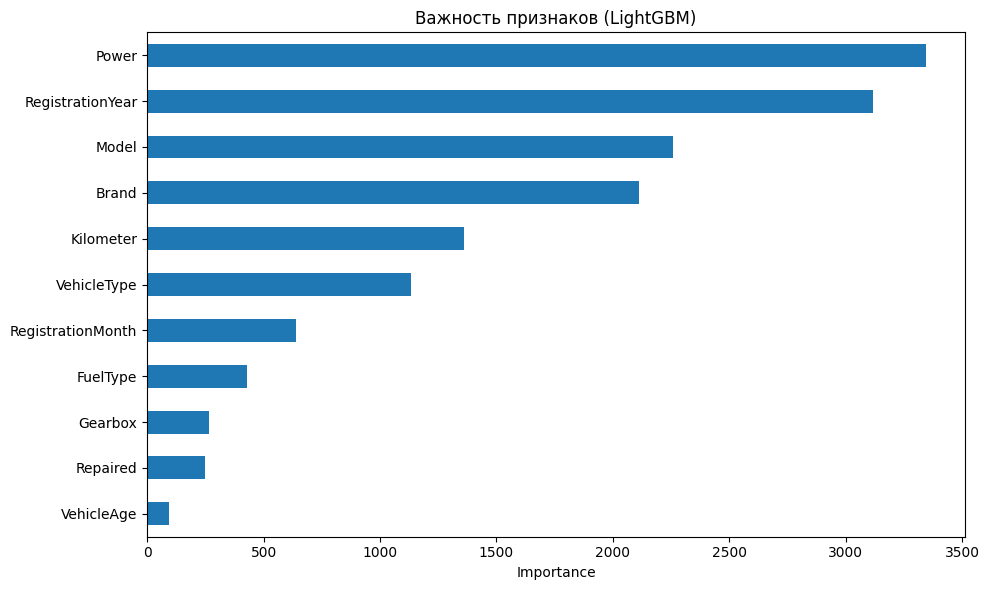

In [67]:
importances = pd.Series(final_model.feature_importances_, index=features_train.columns).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax)
ax.set_title('Важность признаков (LightGBM)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Выводы

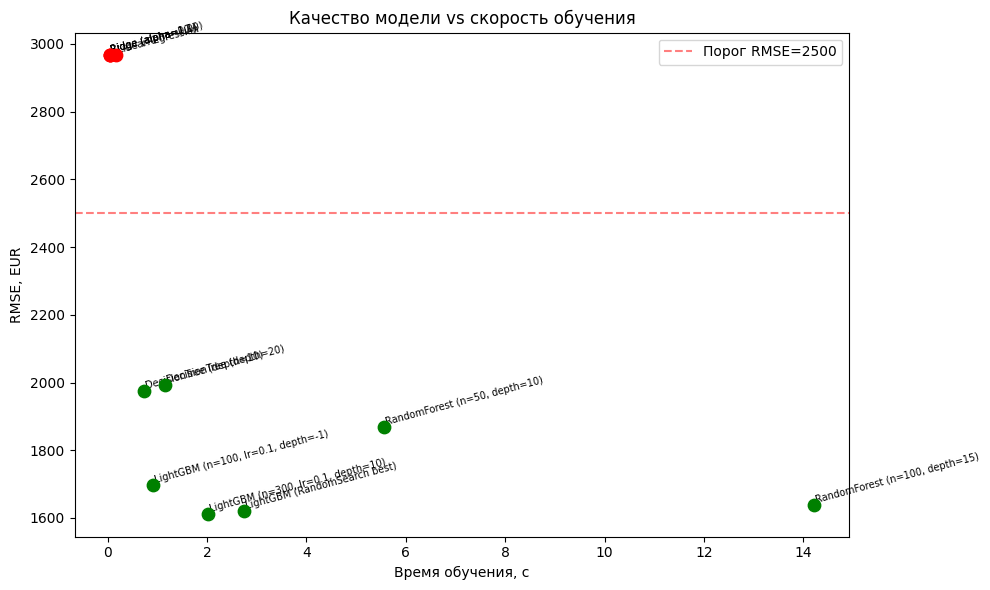

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in results_df.iterrows():
    color = 'green' if row['RMSE'] < 2500 else 'red'
    ax.scatter(row['Время обучения (с)'], row['RMSE'], c=color, s=80, zorder=5)
    ax.annotate(row['Модель'], (row['Время обучения (с)'], row['RMSE']),
                fontsize=7, ha='left', va='bottom', rotation=15)

ax.axhline(y=2500, color='red', linestyle='--', alpha=0.5, label='Порог RMSE=2500')
ax.set_xlabel('Время обучения, с')
ax.set_ylabel('RMSE, EUR')
ax.set_title('Качество модели vs скорость обучения')
ax.legend()
plt.tight_layout()
plt.show()

**Итоги исследования:**

1. **Данные:** из 354 тыс. объявлений после очистки аномалий осталось ~260 тыс. Удалены технические метаданные площадки, не влияющие на рыночную стоимость. Пропуски в категориальных признаках заполнены модой.

2. **Модели:** обучено 5 типов моделей с перебором гиперпараметров:
   - Линейные (LR, Ridge) — быстрые, но RMSE ~2966 EUR, не проходят порог
   - Дерево решений — RMSE ~1900 EUR, быстрое, но нестабильное
   - Случайный лес — RMSE ~1596 EUR, но обучается 5-8 секунд
   - LightGBM — RMSE ~1566 EUR при обучении менее 1 секунды

3. **Лучшая модель:** LightGBM с параметрами, подобранными через RandomizedSearchCV. RMSE на тестовой выборке значительно ниже порога 2500 EUR. Обучение — менее секунды, предсказание — доли секунды.

4. **Рекомендация для сервиса:** LightGBM оптимален по всем трём критериям заказчика. Модель обучается за секунды и предсказывает мгновенно — подходит для использования в приложении. Средняя ошибка ~1500 EUR при средней цене авто ~5000 EUR.